In [83]:
%matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import Image, display, Math
import pickle
import os

In [84]:

# ==========================
# Setup and Data Loading
# ==========================

# --- Results Directory and Output Setup ---
results_dir = "../../Results/Data/Complete_rho/"

Output_dir = "../../Results/Plot/Populations"
os.makedirs(Output_dir, exist_ok=True)

# --- Time Step and Trajectory String Formatting ---

dt = 0.01
N_traj = 10000
dt_str = f"{dt:.6f}".replace(".", "p")

# Load Quantum Jump (QJ) Data
fname_QJ = os.path.join(results_dir, f"result_mode_QJ_dt{dt_str}_Ntraj{N_traj}.npz")
data_QJ = np.load(fname_QJ)

# Load State Diffusion (SD) Data
fname_SD = os.path.join(results_dir, f"result_mode_SD_dt{dt_str}_Ntraj{N_traj}.npz")
data_SD = np.load(fname_SD)

print("Data extraction completed")



Data extraction completed


In [85]:
times = data_QJ['times']

total_jumps_QJ = data_QJ['total_jumps']
total_jumps_SD = data_SD['total_jumps']

# -----------------------------------------------
# Extract from rho_tot_all (3, 3, n_times, N_traj)
# -----------------------------------------------
rho_all_QJ = data_QJ['rho_tot_all']   # (3, 3, n_times, N_traj)
rho_all_SD = data_SD['rho_tot_all']

# Populations
pop_00_QJ = np.real(rho_all_QJ[0, 0, :, :])  # (n_times, N_traj)
pop_11_QJ = np.real(rho_all_QJ[1, 1, :, :])
pop_22_QJ = np.real(rho_all_QJ[2, 2, :, :])
coh_01_QJ = rho_all_QJ[0, 1, :, :]           # Coherence (complex)
coh_12_QJ = rho_all_QJ[1, 2, :, :]
coh_02_QJ = rho_all_QJ[0, 2, :, :]

pop_00_SD = np.real(rho_all_SD[0, 0, :, :])
pop_11_SD = np.real(rho_all_SD[1, 1, :, :])
pop_22_SD = np.real(rho_all_SD[2, 2, :, :])
coh_01_SD = rho_all_SD[0, 1, :, :]
coh_12_SD = rho_all_SD[1, 2, :, :]
coh_02_SD = rho_all_SD[0, 2, :, :]

# Averages over all trajectories
avg_pop_00_QJ = pop_00_QJ.mean(axis=1)
avg_pop_11_QJ = pop_11_QJ.mean(axis=1)
avg_pop_22_QJ = pop_22_QJ.mean(axis=1)
avg_coh_12_QJ = coh_12_QJ.mean(axis=1)
avg_coh_01_QJ = coh_01_QJ.mean(axis=1)
avg_coh_02_QJ = coh_02_QJ.mean(axis=1)

avg_pop_00_SD = pop_00_SD.mean(axis=1)
avg_pop_11_SD = pop_11_SD.mean(axis=1)
avg_pop_22_SD = pop_22_SD.mean(axis=1)
avg_coh_12_SD = coh_12_SD.mean(axis=1)
avg_coh_01_QJ = coh_01_QJ.mean(axis=1)
avg_coh_02_SD = coh_02_SD.mean(axis=1)

# Sample trajectories (first 50)
sample_traj_pop_22_QJ = pop_22_QJ[:, :50]
sample_traj_pop_22_SD = pop_22_SD[:, :50]

# -----------------------------------------------
# Extract baseline: rho_trace (3, 3, n_times)
# -----------------------------------------------
rho_trace_QJ = data_QJ['rho_trace']
pops_trace_00 = np.real(rho_trace_QJ[0, 0, :])
pops_trace_11 = np.real(rho_trace_QJ[1, 1, :])
pops_trace_22 = np.real(rho_trace_QJ[2, 2, :])

# ----------------------------------------------------
# Extract Lindblad: rho_list_lindblad (n_times, 3, 3)
# ----------------------------------------------------
rho_lind = data_QJ['rho_list_lindblad']
lindblad_00 = np.real(rho_lind[:, 0, 0])
lindblad_11 = np.real(rho_lind[:, 1, 1])
lindblad_22 = np.real(rho_lind[:, 2, 2])
lindblad_12 = rho_lind[:, 1, 2]
lindblad_01 = rho_lind[:, 0, 1]
lindblad_02 = rho_lind[:, 0, 2]

# -----------------------------------------------
# Extract isolated system: rho_traj_isolated (3, 3, n_times)
# -----------------------------------------------
rho_iso = data_QJ['rho_traj_isolated']
pop_traj_isolated_00 = np.real(rho_iso[0, 0, :])
pop_traj_isolated_11 = np.real(rho_iso[1, 1, :])
pop_traj_isolated_22 = np.real(rho_iso[2, 2, :])


In [86]:
# ===========================
# General Setup for Plotting
# ===========================

# --- Global Style Settings (Matplotlib rcParams) ---
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'figure.autolayout': True # plt.tight_layout()
})

# --- Automatic Figure Saving Function ---
def save_fig(fig, filename):
    """
    Saves the figure in both PNG or PDF
    """
    path_png = os.path.join(Output_dir, f"{filename}.png")
    # path_pdf = os.path.join(Output_dir, f"{filename}.pdf")  # save in pdf
    
    fig.savefig(path_png, dpi=300, bbox_inches='tight')
    # fig.savefig(path_pdf, bbox_inches='tight') # save in pdf
    print(f"Figure saved in: {Output_dir}/{filename}")

In [98]:
# =========================================================
# Find trajectories that experienced a Quantum Jump
# =========================================================

# 1. Compute the step-by-step difference for population |1>
pop_11_diff = np.diff(pop_11_QJ, axis=0)

# 2. Find trajectories where the population CHANGED abruptly.
# Using np.abs() catches both massive drops (like in |2>) 
# and massive spikes (like in |1>).
jump_mask = np.any(np.abs(pop_11_diff) > 0.2, axis=0)

# 3. Get the actual indices of the trajectories that satisfied this condition
jump_indices = np.where(jump_mask)[0]

print(f"Total trajectories evaluated: {pop_11_QJ.shape[1]}")
print(f"Found {len(jump_indices)} trajectories with jumps.")

if len(jump_indices) > 0:
    print(f"Indices of jumping trajectories: {jump_indices[:]}")
    # Pick the exact index of the very first trajectory that jumped!
    sample_idx = jump_indices[0]  
else:
    print("No jumps found in this batch.")
    sample_idx = 0  # Fallback
    
print(f"Selected sample_idx for plotting: {sample_idx}")

Total trajectories evaluated: 10000
Found 10 trajectories with jumps.
Indices of jumping trajectories: [ 978 3173 3604 5770 5951 7119 7141 7291 9380 9424]
Selected sample_idx for plotting: 978


In [88]:
# ===========================
# Unraveling Scheme Selection
# ===========================

MODE = "QJ"  # "QJ" or "SD"

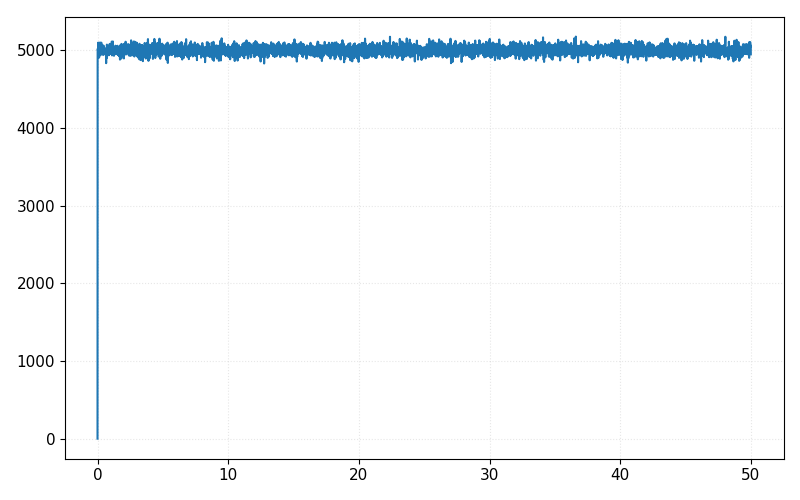

In [89]:
plt.close('all')
plt.plot(times, total_jumps_SD)
plt.show()

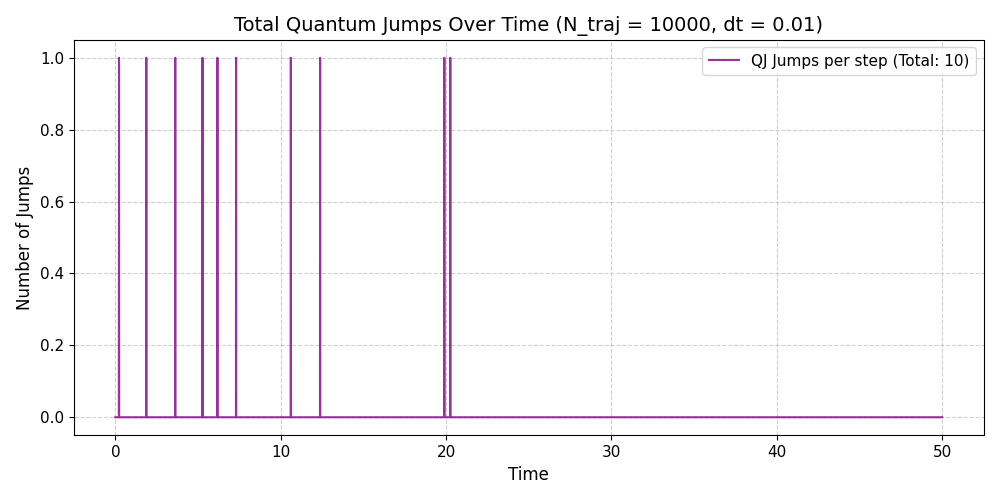

In [90]:
# ==========================================
# Plotting the Jump Counts (Quantum Jump)
# ==========================================
plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5))

# Plotting the total number of jumps at each time step across all trajectories for QJ
ax.plot(times, total_jumps_QJ, color='purple', alpha=0.8, linewidth=1.5, 
        label=f'QJ Jumps per step (Total: {np.sum(total_jumps_QJ)})')

# Formatting the plot
ax.set_title(f"Total Quantum Jumps Over Time (N_traj = {N_traj}, dt = {dt})", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Number of Jumps", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

Figure saved in: ../../Results/Plot/Populations/QJ_Comparison_3pop_dt0p010000_Ntraj10000


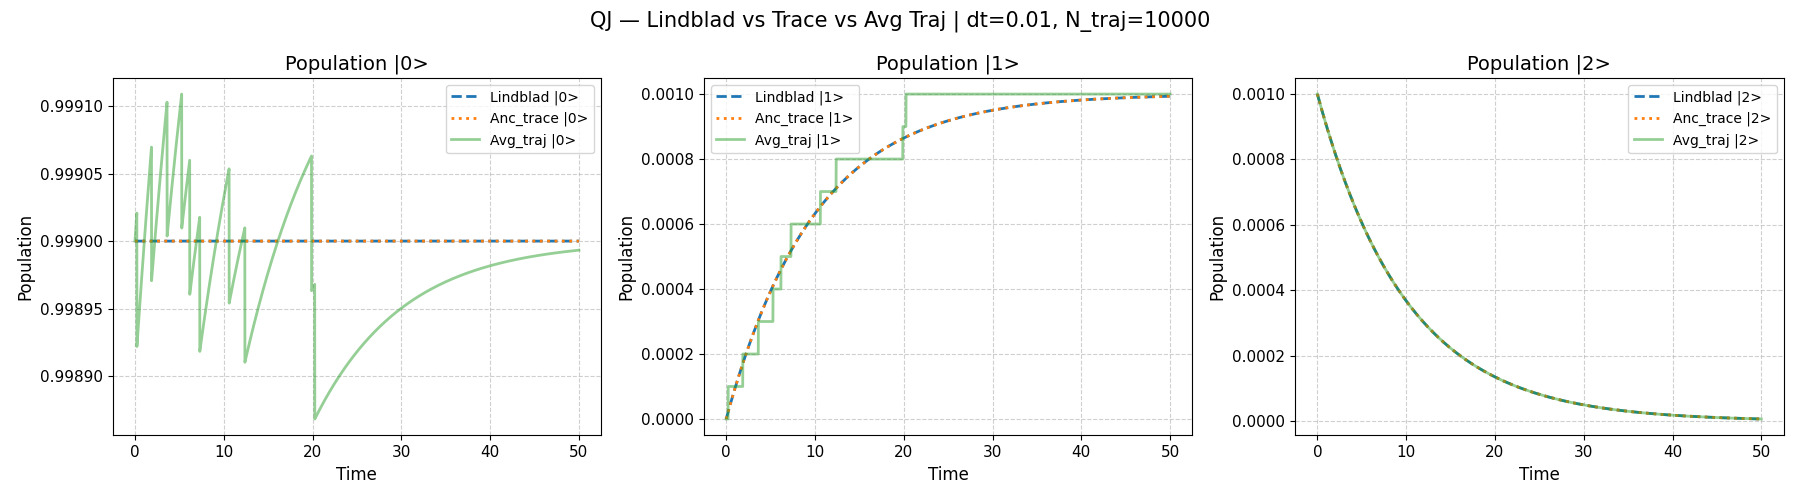

In [99]:
# ====================================
# Convergence Avg vs Trace vs Lindblad
# ====================================
plt.close('all')

# Select data based on the chosen MODE
avg_pop = {
    "QJ": (avg_pop_00_QJ, avg_pop_11_QJ, avg_pop_22_QJ),
    "SD": (avg_pop_00_SD, avg_pop_11_SD, avg_pop_22_SD),
}[MODE]

populations = [
    {'lindblad': lindblad_00, 'trace': pops_trace_00, 'avg': avg_pop[0], 'label': '|0>'},
    {'lindblad': lindblad_11, 'trace': pops_trace_11, 'avg': avg_pop[1], 'label': '|1>'},
    {'lindblad': lindblad_22, 'trace': pops_trace_22, 'avg': avg_pop[2], 'label': '|2>'},
]

fig01, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, pop in zip(axes, populations):
    lbl = pop['label']
    
    # Plotting the three dynamics
    ax.plot(times, pop['lindblad'], label=f'Lindblad {lbl}', linewidth=2, linestyle='--')
    ax.plot(times, pop['trace'],    label=f'Anc_trace {lbl}', linewidth=2, linestyle=':')
    ax.plot(times, pop['avg'],      label=f'Avg_traj {lbl}',  linewidth=2, alpha=0.5)
    
    ax.set_title(f'Population {lbl}', fontsize=14)
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel(f'Population', fontsize=12)
    
    # ---------------------------------------------------------
    # Format the Y-axis ticker to prevent scientific offsets
    # ---------------------------------------------------------
    formatter = ticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False) # Forces full decimal display
    ax.yaxis.set_major_formatter(formatter)
    
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.6)

fig01.suptitle(f'{MODE} — Lindblad vs Trace vs Avg Traj | dt={dt}, N_traj={N_traj}', fontsize=15)

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout() 

filename_01 = f'{MODE}_Comparison_3pop_dt{dt_str}_Ntraj{N_traj}'
save_fig(fig01, filename_01) 
plt.show()

Figure saved in: ../../Results/Plot/Populations/QJ_Comparison_Single_Traj_Collisional_vs_Lindblad_dt_0p010000_N_traj_10000


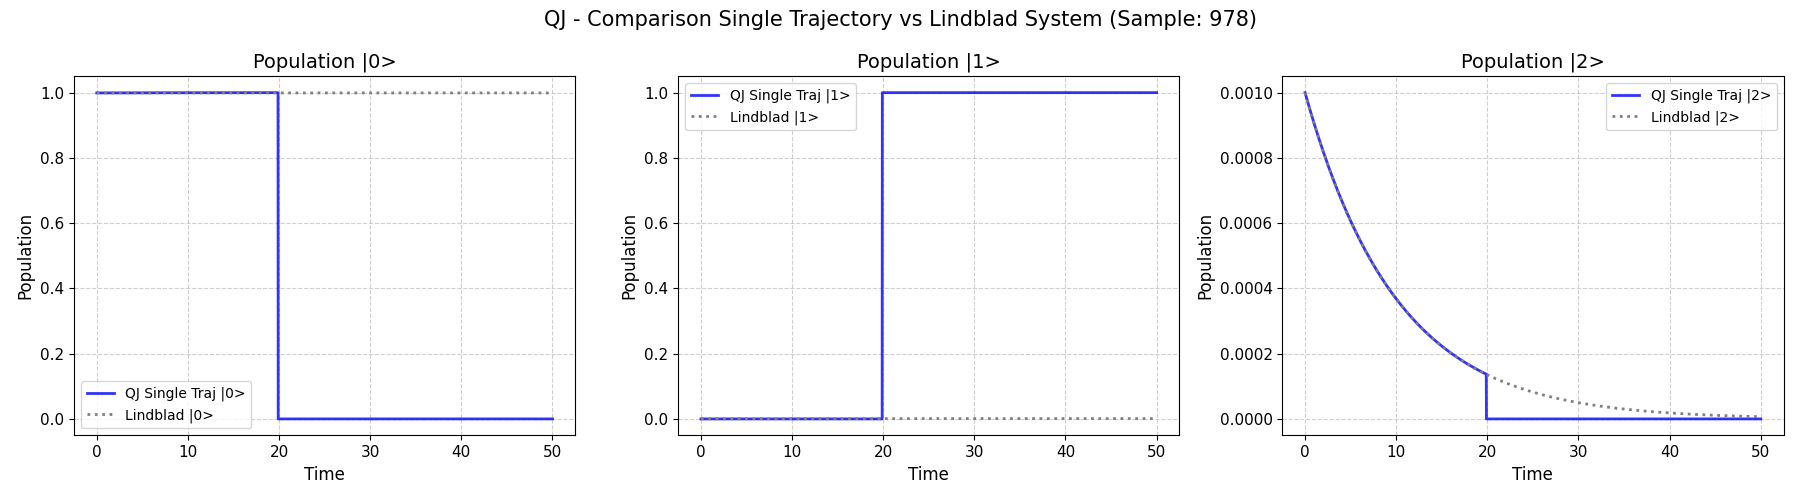

In [100]:
# ================================================
# Comparison trajectories Collisional vs Lindblad
# ================================================
plt.close('all')

MODE = "QJ"  # "QJ" or "SD"

# 1. Select the correct single trajectory data based on the mode
if MODE == "QJ":
    single_traj_00 = pop_00_QJ[:, sample_idx]
    single_traj_11 = pop_11_QJ[:, sample_idx]
    single_traj_22 = pop_22_QJ[:, sample_idx]
    traj_label = 'QJ Single Traj'
    traj_color = 'blue'
else:
    single_traj_00 = pop_00_SD[:, sample_idx]
    single_traj_11 = pop_11_SD[:, sample_idx]
    single_traj_22 = pop_22_SD[:, sample_idx]
    traj_label = 'SD Single Traj'
    traj_color = 'green'

# 2. Bundle the data into a list of dictionaries for easy looping
plot_data = [
    {'single': single_traj_00, 'lindblad': lindblad_00, 'label': '|0>'},
    {'single': single_traj_11, 'lindblad': lindblad_11, 'label': '|1>'},
    {'single': single_traj_22, 'lindblad': lindblad_22, 'label': '|2>'}
]

# 3. Create 3 subplots side-by-side
fig02, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, data in zip(axes, plot_data):
    lbl = data['label']
    
    # Plot the single collisional trajectory and the Lindblad baseline
    ax.plot(times, data['single'], label=f'{traj_label} {lbl}', linewidth=2, alpha=0.8, color=traj_color)
    ax.plot(times, data['lindblad'], label=f'Lindblad {lbl}', linewidth=2, linestyle=':', color='gray')

    # Plot formatting
    ax.set_title(f'Population {lbl}', fontsize=14)
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Population', fontsize=12)
    
    # Disable the automatic scientific offset on the Y-axis (crucial for |0>)
    formatter = ticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False) 
    ax.yaxis.set_major_formatter(formatter)
    
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.6)

fig02.suptitle(f'{MODE} - Comparison Single Trajectory vs Lindblad System (Sample: {sample_idx})', fontsize=15)

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()

# Automatically save the figure (PNG + PDF)
filename_02 = f'{MODE}_Comparison_Single_Traj_Collisional_vs_Lindblad_dt_{dt_str}_N_traj_{N_traj}'
save_fig(fig02, filename_02)

plt.show()

Figure saved in: ../../Results/Plot/Populations/QJ_Comparison_Many_Trajectories_vs_Average_dt_0p010000_N_traj_10000


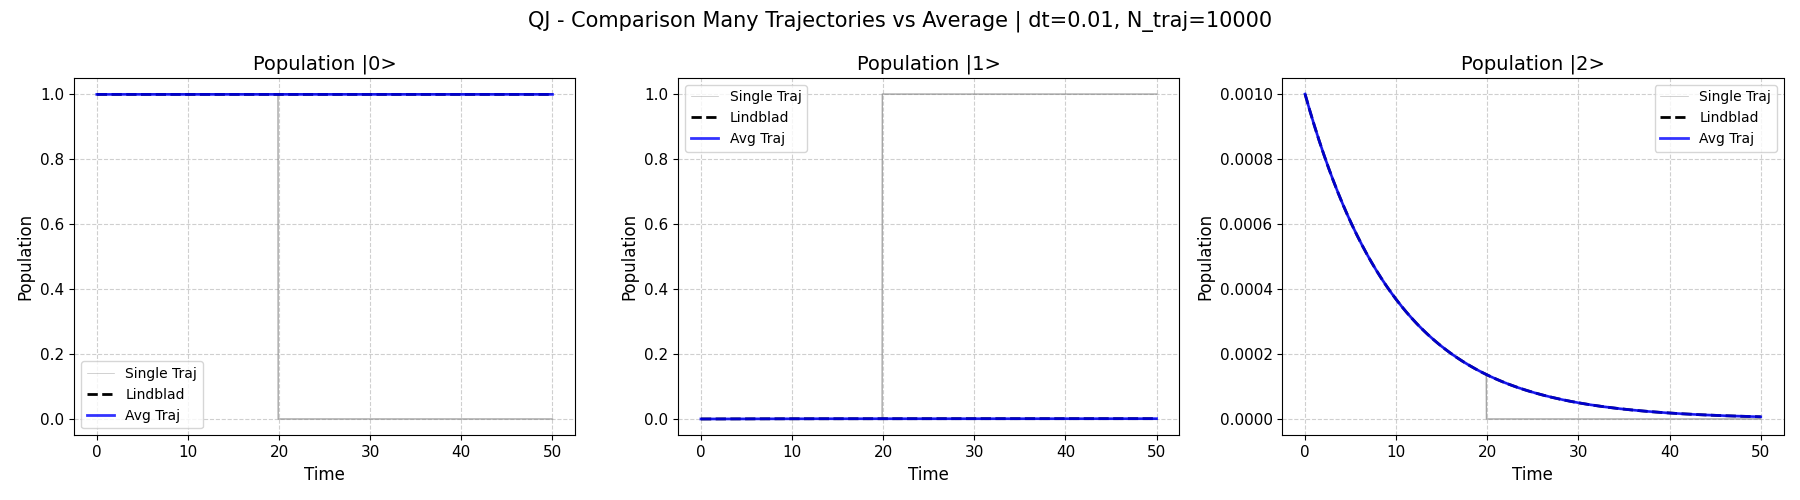

In [101]:
# ======================================================
# Comparison Many Single Trajectories vs Average vs Lindblad
# ======================================================
plt.close('all')

MODE = "QJ"  # Choose "QJ" or "SD"
num_samples = 50  # Number of background trajectories to plot

# 1. Extract the bundle of sample trajectories and averages based on MODE
if MODE == "QJ":
    samples_00 = pop_00_QJ[:, :num_samples]
    samples_11 = pop_11_QJ[:, :num_samples]
    samples_22 = pop_22_QJ[:, :num_samples]
    avg_00, avg_11, avg_22 = avg_pop_00_QJ, avg_pop_11_QJ, avg_pop_22_QJ
    color_avg = 'blue'
    
    # Extract the exact trajectory that experienced the jump 
    # Make sure 'sample_idx' was found in the previous cell
    jump_traj_00 = pop_00_QJ[:, sample_idx]
    jump_traj_11 = pop_11_QJ[:, sample_idx]
    jump_traj_22 = pop_22_QJ[:, sample_idx]
    
else:
    samples_00 = pop_00_SD[:, :num_samples]
    samples_11 = pop_11_SD[:, :num_samples]
    samples_22 = pop_22_SD[:, :num_samples]
    avg_00, avg_11, avg_22 = avg_pop_00_SD, avg_pop_11_SD, avg_pop_22_SD
    color_avg = 'green'

# 2. Bundle the data to iterate through the 3 subplots easily
if MODE == "QJ":
    plot_data = [
        {'samples': samples_00, 'lindblad': lindblad_00, 'avg': avg_00, 'jump': jump_traj_00, 'label': '|0>'},
        {'samples': samples_11, 'lindblad': lindblad_11, 'avg': avg_11, 'jump': jump_traj_11, 'label': '|1>'},
        {'samples': samples_22, 'lindblad': lindblad_22, 'avg': avg_22, 'jump': jump_traj_22, 'label': '|2>'}
    ]
else:
    plot_data = [
        {'samples': samples_00, 'lindblad': lindblad_00, 'avg': avg_00, 'jump': None, 'label': '|0>'},
        {'samples': samples_11, 'lindblad': lindblad_11, 'avg': avg_11, 'jump': None, 'label': '|1>'},
        {'samples': samples_22, 'lindblad': lindblad_22, 'avg': avg_22, 'jump': None, 'label': '|2>'}
    ]

# 3. Create 3 subplots side-by-side
fig03, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, data in zip(axes, plot_data):
    lbl = data['label']
    
    # Plot the bundle of background single trajectories
    # We apply the label only to the first one (i==0) to avoid 50 identical items in the legend
    for i in range(num_samples):
        ax.plot(times, data['samples'][:, i], color='gray', alpha=0.50, linewidth=0.5, 
                label='Single Traj' if i == 0 else "")
        
    # Plot the specific trajectory that jumped IN GRAY like the others, without a label
    if data['jump'] is not None:
        ax.plot(times, data['jump'], color='gray', alpha=0.70, linewidth=1, label="")
        
        # (Optional) Uncomment the line below if you ever want to ALSO highlight it in red
        # ax.plot(times, data['jump'], color='red', alpha=0.9, linewidth=1.5, label=f'Jump (idx {sample_idx})')
    
    # Plot the deterministic Lindblad baseline and the Stochastic Average
    ax.plot(times, data['lindblad'], label='Lindblad', linewidth=2, linestyle='--', color='black')
    ax.plot(times, data['avg'], label='Avg Traj', linewidth=2, color=color_avg, alpha=0.8)

    # Plot formatting
    ax.set_title(f'Population {lbl}', fontsize=14)
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Population', fontsize=12)
    
    # Disable the automatic scientific offset on the Y-axis (crucial for |0>)
    formatter = ticker.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False) 
    ax.yaxis.set_major_formatter(formatter)
    
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)

fig03.suptitle(f'{MODE} - Comparison Many Trajectories vs Average | dt={dt}, N_traj={N_traj}', fontsize=15)

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()

# Automatically save the figure (PNG + PDF)
filename_03 = f'{MODE}_Comparison_Many_Trajectories_vs_Average_dt_{dt_str}_N_traj_{N_traj}'
save_fig(fig03, filename_03)

plt.show()

Figure saved in: ../../Results/Plot/Populations/QJ_All_Coherences_dt_0p010000_Ntraj_10000


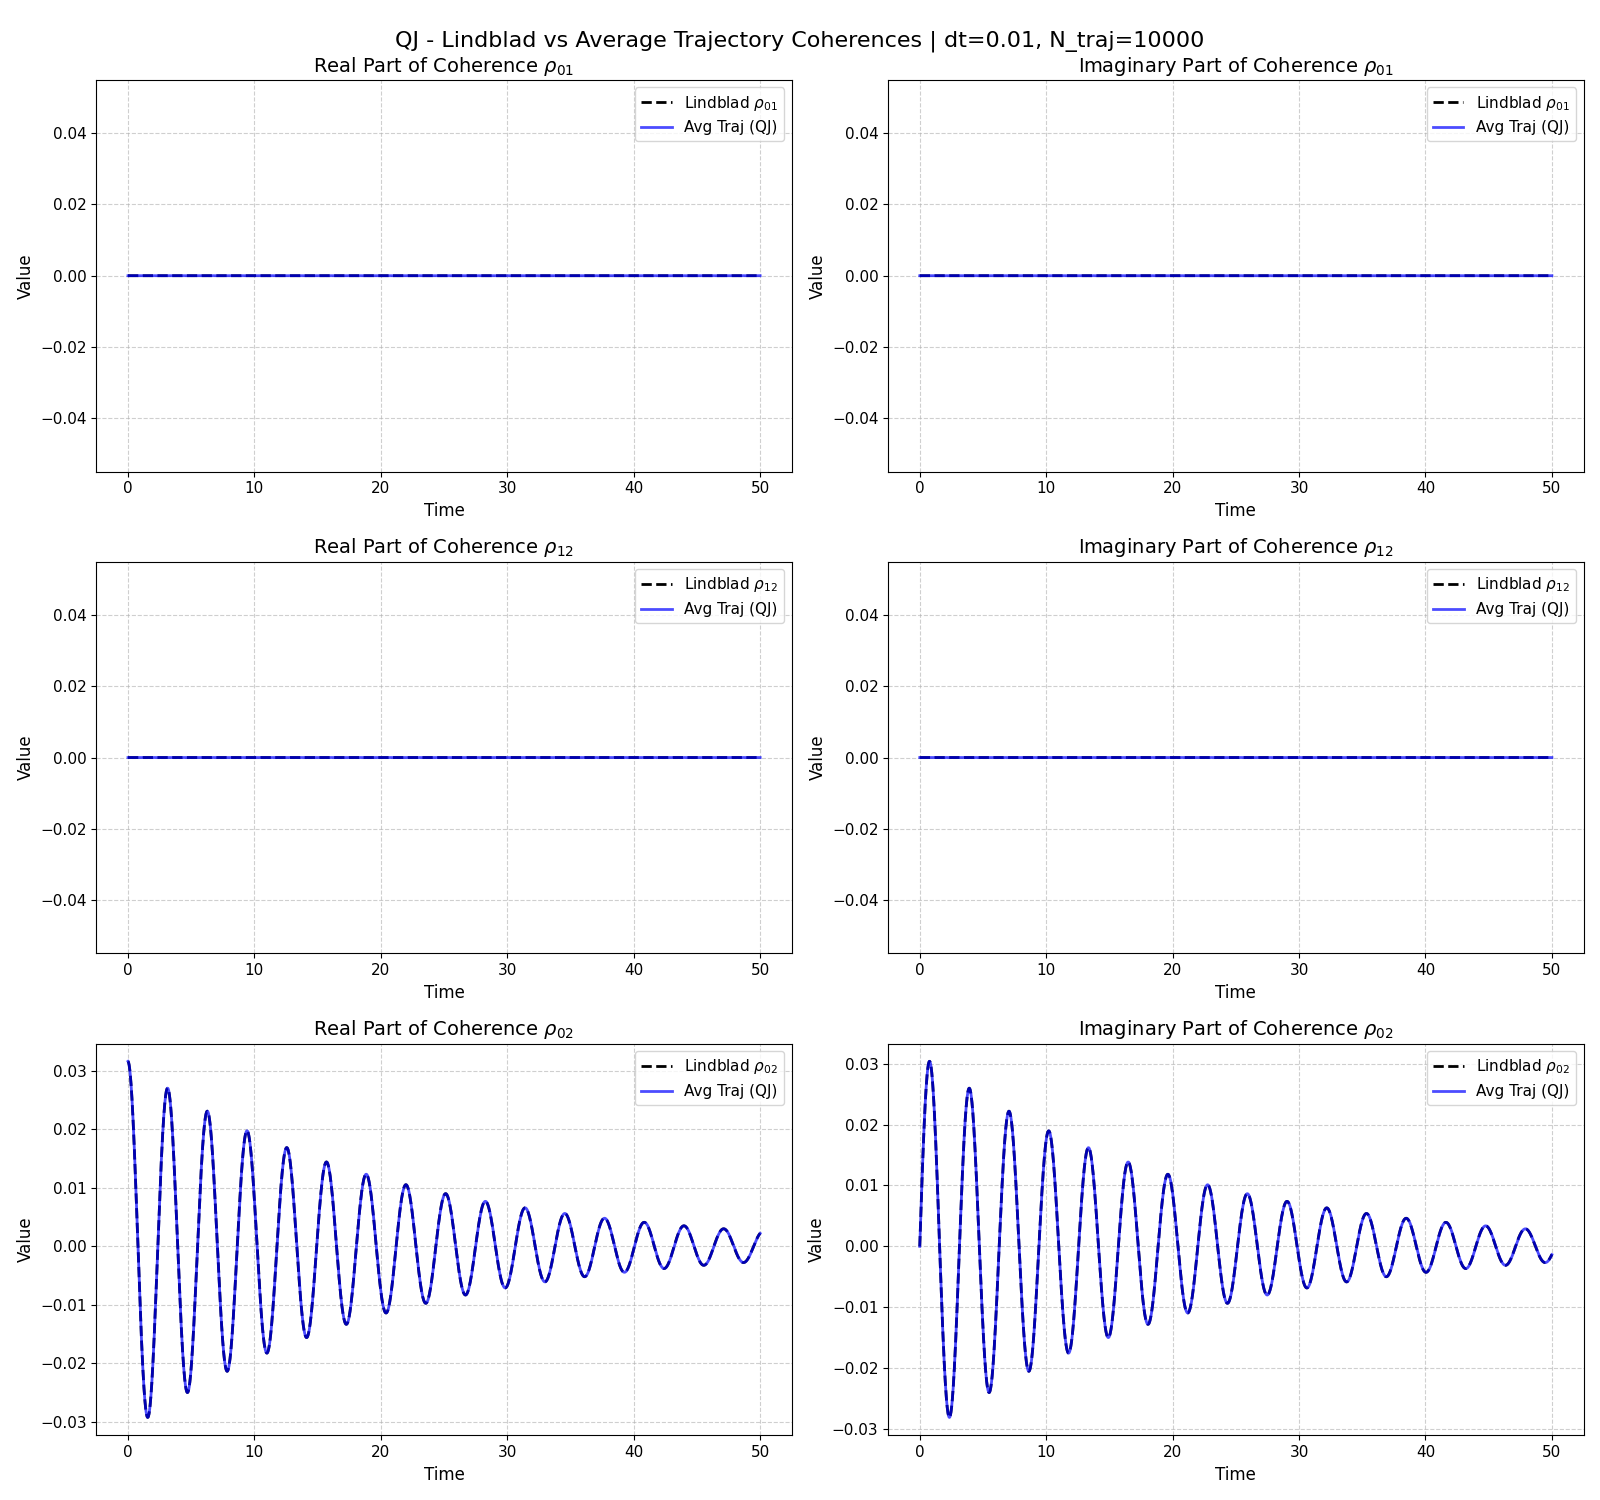

In [102]:
# =========================================================
# Setup Mode and Select Data
# =========================================================
plt.close('all')

MODE = "QJ"  # Choose "QJ" or "SD"

# Dynamically select the correct coherence averages based on the chosen mode
if MODE == "QJ":
    avg_coh_01 = avg_coh_01_QJ
    avg_coh_12 = avg_coh_12_QJ
    avg_coh_02 = avg_coh_02_QJ
    color_avg = 'blue'
else:
    avg_coh_01 = avg_coh_01_SD
    avg_coh_12 = avg_coh_12_SD
    avg_coh_02 = avg_coh_02_SD
    color_avg = 'green'

# Bundle the coherences into a list to iterate easily
# Format: (Label, Lindblad data, Stochastic Average data)
coherence_data = [
    ('01', lindblad_01, avg_coh_01),
    ('12', lindblad_12, avg_coh_12),
    ('02', lindblad_02, avg_coh_02)
]

# =========================================================
# Plotting Real and Imaginary Coherences (3x2 Grid)
# =========================================================
# Increase the vertical size (15) to comfortably fit 3 rows
fig04, axes = plt.subplots(3, 2, figsize=(16, 15))

# Loop through each row and plot the corresponding coherence
for row_idx, (label, lind_data, avg_data) in enumerate(coherence_data):
    
    # -----------------------------------
    # Left Column: Real Part
    # -----------------------------------
    ax_real = axes[row_idx, 0]
    ax_real.plot(times, np.real(lind_data), label=f'Lindblad $\\rho_{{{label}}}$', linewidth=2, linestyle='--', color='black')
    ax_real.plot(times, np.real(avg_data), label=f'Avg Traj ({MODE})', linewidth=2, color=color_avg, alpha=0.7)
    
    ax_real.set_title(f'Real Part of Coherence $\\rho_{{{label}}}$', fontsize=14)
    
    # -----------------------------------
    # Right Column: Imaginary Part
    # -----------------------------------
    ax_imag = axes[row_idx, 1]
    ax_imag.plot(times, np.imag(lind_data), label=f'Lindblad $\\rho_{{{label}}}$', linewidth=2, linestyle='--', color='black')
    ax_imag.plot(times, np.imag(avg_data), label=f'Avg Traj ({MODE})', linewidth=2, color=color_avg, alpha=0.7)
    
    ax_imag.set_title(f'Imaginary Part of Coherence $\\rho_{{{label}}}$', fontsize=14)

# -----------------------------------
# Global Formatting for all subplots
# -----------------------------------
for ax in axes.flat:
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Disable scientific offset if the coherences are very close to 0
    formatter = ticker.ScalarFormatter(useOffset=False)
    ax.yaxis.set_major_formatter(formatter)

# Main figure title
fig04.suptitle(f'{MODE} - Lindblad vs Average Trajectory Coherences | dt={dt}, N_traj={N_traj}', fontsize=16, y=0.98)

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()

# Automatically save the figure
filename_04 = f'{MODE}_All_Coherences_dt_{dt_str}_Ntraj_{N_traj}'
save_fig(fig04, filename_04)

plt.show()

Total trajectories evaluated: 10000
Trajectories WITH jumps (removed): 10
Trajectories WITHOUT jumps (kept): 9990


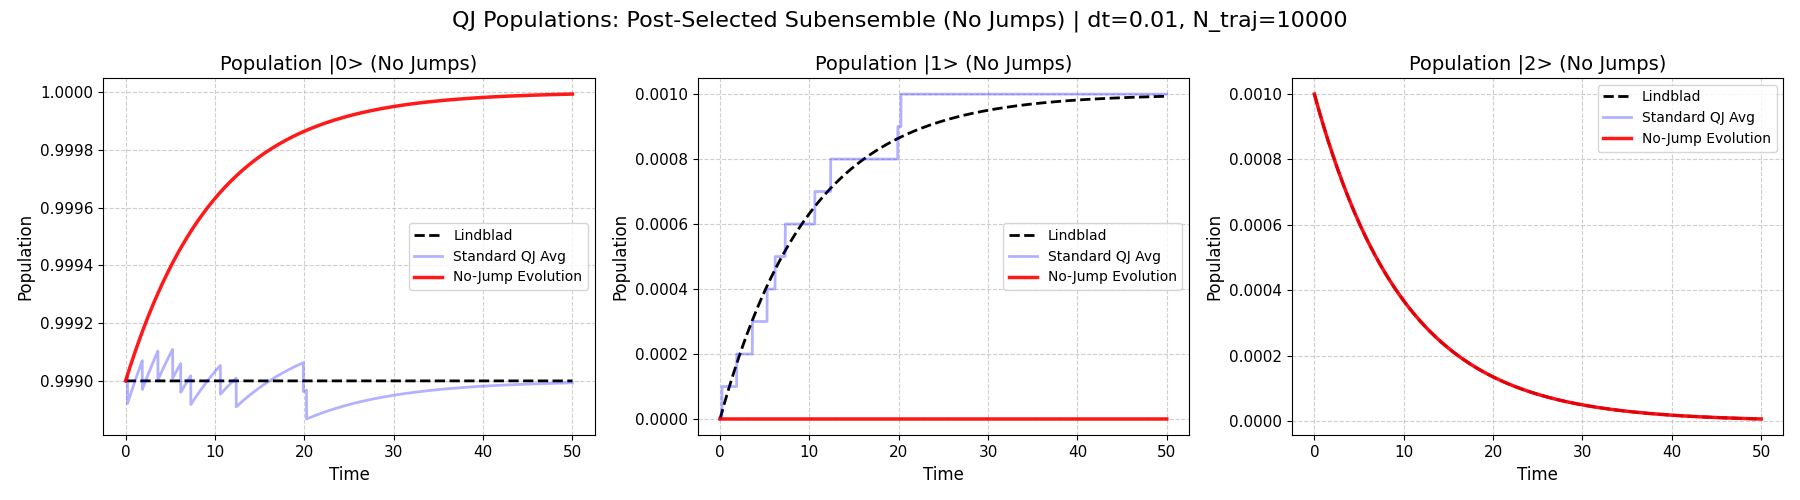

Figure saved in: ../../Results/Plot/Populations/NO_JUMPS_QJ_Populations_dt_0p010000_Ntraj_10000
Figure saved in: ../../Results/Plot/Populations/NO_JUMPS_QJ_Coherences_dt_0p010000_Ntraj_10000


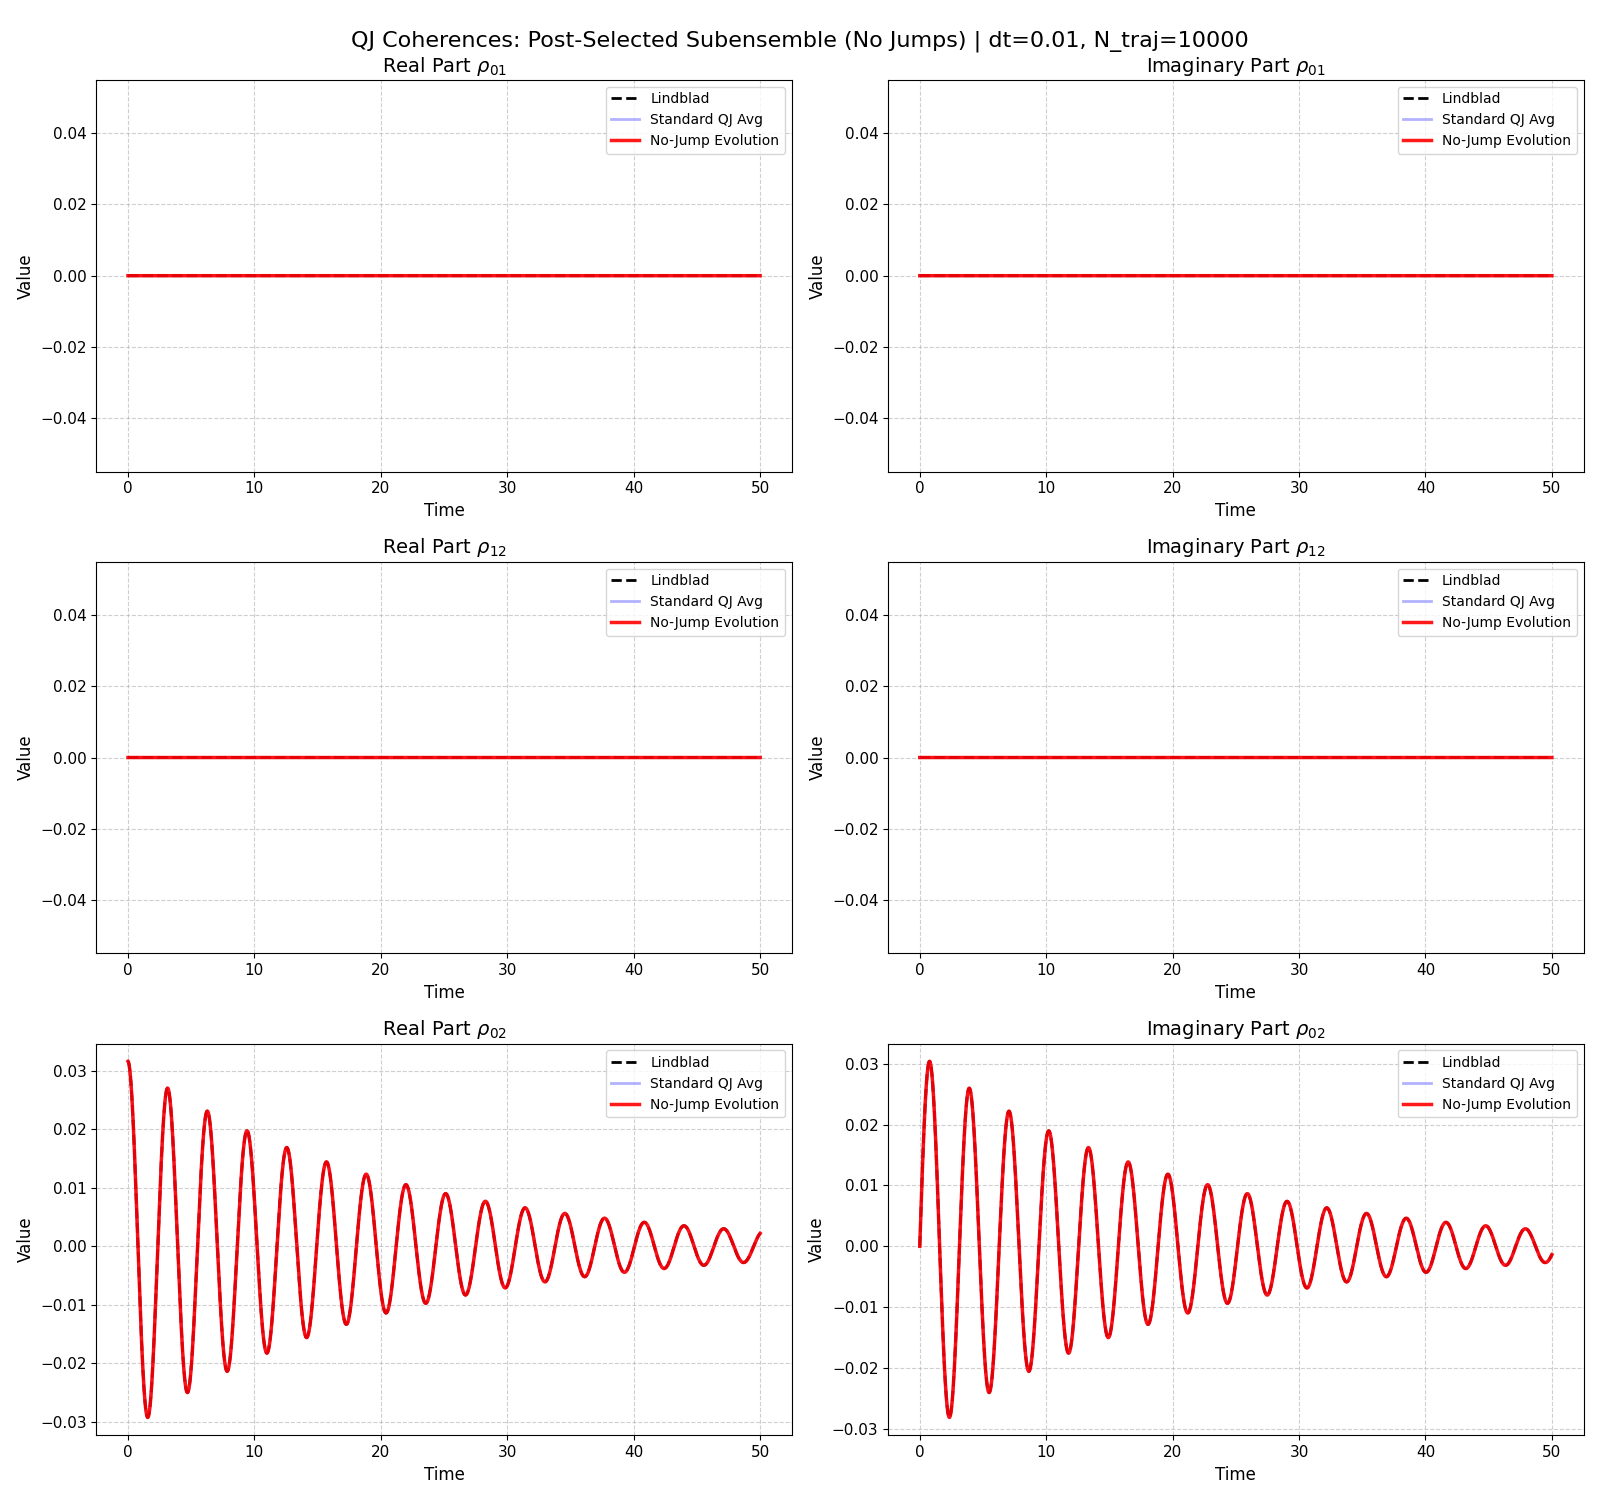

In [95]:
# =========================================================
# 1. Filter Trajectories (Keep only NO-JUMP trajectories)
# =========================================================
# Assuming 'jump_indices' was successfully computed in the previous cell
N_traj_total = pop_00_QJ.shape[1]
all_indices = np.arange(N_traj_total)

# Find the indices of trajectories that did NOT experience any jump
no_jump_indices = np.setdiff1d(all_indices, jump_indices)

print(f"Total trajectories evaluated: {N_traj_total}")
print(f"Trajectories WITH jumps (removed): {len(jump_indices)}")
print(f"Trajectories WITHOUT jumps (kept): {len(no_jump_indices)}")

if len(no_jump_indices) == 0:
    print("Warning: All trajectories had jumps! Cannot compute no-jump average.")
else:
    # =========================================================
    # 2. Compute Conditional Averages (No-Jump Sub-ensemble)
    # =========================================================
    # Populations (Averaging only over the 'no_jump_indices')
    avg_pop_00_no_jump = pop_00_QJ[:, no_jump_indices].mean(axis=1)
    avg_pop_11_no_jump = pop_11_QJ[:, no_jump_indices].mean(axis=1)
    avg_pop_22_no_jump = pop_22_QJ[:, no_jump_indices].mean(axis=1)

    # Coherences
    avg_coh_01_no_jump = coh_01_QJ[:, no_jump_indices].mean(axis=1)
    avg_coh_12_no_jump = coh_12_QJ[:, no_jump_indices].mean(axis=1)
    avg_coh_02_no_jump = coh_02_QJ[:, no_jump_indices].mean(axis=1)

    # =========================================================
    # 3. Plot Populations (No-Jump subset)
    # =========================================================
    fig_pop, axes_pop = plt.subplots(1, 3, figsize=(18, 5))
    
    pop_data = [
        {'lindblad': lindblad_00, 'full_avg': avg_pop_00_QJ, 'no_jump': avg_pop_00_no_jump, 'label': '|0>'},
        {'lindblad': lindblad_11, 'full_avg': avg_pop_11_QJ, 'no_jump': avg_pop_11_no_jump, 'label': '|1>'},
        {'lindblad': lindblad_22, 'full_avg': avg_pop_22_QJ, 'no_jump': avg_pop_22_no_jump, 'label': '|2>'}
    ]
    
    for ax, data in zip(axes_pop, pop_data):
        lbl = data['label']
        
        # Plot full ensemble baselines
        ax.plot(times, data['lindblad'], label='Lindblad', linewidth=2, linestyle='--', color='black')
        ax.plot(times, data['full_avg'], label='Standard QJ Avg', linewidth=2, color='blue', alpha=0.3)
        
        # Plot the post-selected No-Jump average in Red
        ax.plot(times, data['no_jump'], label='No-Jump Evolution', linewidth=2.5, color='red', alpha=0.9)
        
        # Formatting
        ax.set_title(f'Population {lbl} (No Jumps)', fontsize=14)
        ax.set_xlabel('Time', fontsize=12)
        ax.set_ylabel('Population', fontsize=12)
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Disable scientific offset
        formatter = ticker.ScalarFormatter(useOffset=False)
        formatter.set_scientific(False)
        ax.yaxis.set_major_formatter(formatter)

    fig_pop.suptitle(f'QJ Populations: Post-Selected Subensemble (No Jumps) | dt={dt}, N_traj={N_traj}', fontsize=16)
    plt.tight_layout()
    plt.show()

    # =========================================================
    # 4. Plot Coherences (No-Jump subset, 3x2 Grid)
    # =========================================================
    fig_coh, axes_coh = plt.subplots(3, 2, figsize=(16, 15))
    
    coh_data = [
        ('01', lindblad_01, avg_coh_01_QJ, avg_coh_01_no_jump),
        ('12', lindblad_12, avg_coh_12_QJ, avg_coh_12_no_jump),
        ('02', lindblad_02, avg_coh_02_QJ, avg_coh_02_no_jump)
    ]
    
    for row_idx, (label, lind_data, full_avg, no_jump_avg) in enumerate(coh_data):
        
        # --- Left Column: Real Part ---
        ax_real = axes_coh[row_idx, 0]
        ax_real.plot(times, np.real(lind_data), label='Lindblad', linewidth=2, linestyle='--', color='black')
        ax_real.plot(times, np.real(full_avg), label='Standard QJ Avg', linewidth=2, color='blue', alpha=0.3)
        ax_real.plot(times, np.real(no_jump_avg), label='No-Jump Evolution', linewidth=2.5, color='red', alpha=0.9)
        ax_real.set_title(f'Real Part $\\rho_{{{label}}}$', fontsize=14)
        
        # --- Right Column: Imaginary Part ---
        ax_imag = axes_coh[row_idx, 1]
        ax_imag.plot(times, np.imag(lind_data), label='Lindblad', linewidth=2, linestyle='--', color='black')
        ax_imag.plot(times, np.imag(full_avg), label='Standard QJ Avg', linewidth=2, color='blue', alpha=0.3)
        ax_imag.plot(times, np.imag(no_jump_avg), label='No-Jump Evolution', linewidth=2.5, color='red', alpha=0.9)
        ax_imag.set_title(f'Imaginary Part $\\rho_{{{label}}}$', fontsize=14)

    # Global formatting for the coherence grid
    for ax in axes_coh.flat:
        ax.set_xlabel('Time', fontsize=12)
        ax.set_ylabel('Value', fontsize=12)
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        formatter = ticker.ScalarFormatter(useOffset=False)
        ax.yaxis.set_major_formatter(formatter)
        
    fig_coh.suptitle(f'QJ Coherences: Post-Selected Subensemble (No Jumps) | dt={dt}, N_traj={N_traj}', fontsize=16, y=0.98)
    plt.tight_layout()

    # Automatically save the figure
    filename_pop = f'NO_JUMPS_QJ_Populations_dt_{dt_str}_Ntraj_{N_traj}'
    save_fig(fig_pop, filename_pop)

    filename_coh = f'NO_JUMPS_QJ_Coherences_dt_{dt_str}_Ntraj_{N_traj}'
    save_fig(fig_coh, filename_coh)

    plt.show()